In [1]:
import math
import random
from collections import Counter

def assign_non_developer_teams_rule_based(students, division_type, max_members=None, total_teams=None):
    n_students = len(students)
    if n_students == 0: return [], []

    # --- 팀 수 및 목표 인원 계산 ---
    if division_type == "BY_MEMBER_COUNT":
        if max_members is None:
            raise ValueError("BY_MEMBER_COUNT requires max_members")
        num_final_teams = max(1, (n_students + max_members - 1) // max_members)
    elif division_type == "BY_TEAM_COUNT":
        if total_teams is None:
            raise ValueError("BY_TEAM_COUNT requires total_teams")
        num_final_teams = total_teams
    else:
        raise ValueError("Invalid division_type")

    base_size = n_students // num_final_teams
    target_sizes = [base_size] * num_final_teams
    for i in range(n_students % num_final_teams):
        target_sizes[i] += 1

    teams = [[] for _ in range(num_final_teams)]
    team_leaders_info = [None] * num_final_teams
    assigned_students_names = set()
    students_list = list(students)

    # --- 리더 선정 (기존과 동일) ---
    sorted_students = sorted(students_list, key=lambda x: x["leader_score"], reverse=True)
    for i in range(num_final_teams):
        if i < len(sorted_students):
            leader = sorted_students[i]
            teams[i].append(leader)
            team_leaders_info[i] = leader["name"]
            assigned_students_names.add(leader["name"])

    # --- 남은 인원 동시 조건 기반 배정 ---
    remaining_students = [s for s in students_list if s["name"] not in assigned_students_names]
    random.shuffle(remaining_students)

    for student in remaining_students:
        # 현재 인원 미달 팀만 후보
        candidate_teams = [i for i in range(num_final_teams) if len(teams[i]) < target_sizes[i]]

        # 각 팀에 배정했을 때의 E/I, 기질 평가
        evaluations = []
        for idx in candidate_teams:
            team = teams[idx]
            # E/I 포함여부
            e_in_team = any(m['ei'] == 'E' for m in team)
            i_in_team = any(m['ei'] == 'I' for m in team)
            fills_ei_need = (not e_in_team and student['ei'] == 'E') or (not i_in_team and student['ei'] == 'I')

            e_count = sum(1 for m in team if m['ei'] == 'E')
            i_count = sum(1 for m in team if m['ei'] == 'I')
            new_e_count = e_count + (1 if student['ei'] == 'E' else 0)
            new_i_count = i_count + (1 if student['ei'] == 'I' else 0)
            ei_diff_after = abs(new_e_count - new_i_count)

            # 기질 다양성
            temp_set = set(m['temperament'] for m in team)
            fills_temp_need = student['temperament'] not in temp_set
            temp_dup_count = sum(1 for m in team if m['temperament'] == student['temperament'])
            temp_diversity_after = len(temp_set | {student['temperament']})

            evaluations.append({
                'idx': idx,
                'fills_ei_need': fills_ei_need,  # E/I 한쪽이 아예 없는 팀에 채우는 경우
                'ei_diff_after': -ei_diff_after,  # E/I 차이가 작아지게 되는가
                'fills_temp_need': fills_temp_need,  # 새로운 기질 채워주는 경우
                'temp_diversity_after': temp_diversity_after,  # 기질 다양성 늘리면 가점
                'temp_dup_count': -temp_dup_count,  # 중복 많이 되면 감점
                'current_size': len(team)
            })

        # 우선순위: E/I 결핍 채움 → 기질 다양성 증가 → E/I 차이 감소 → 기질 중복 감소 → 팀 크기(작은 팀 우선)
        evaluations.sort(key=lambda x: (
            x['fills_ei_need'],
            x['fills_temp_need'],
            x['temp_diversity_after'],
            x['ei_diff_after'],
            x['temp_dup_count'],
            -x['current_size']
        ), reverse=True)

        # 최적 팀에 배정
        best_idx = evaluations[0]['idx']
        teams[best_idx].append(student)
        assigned_students_names.add(student["name"])

    return teams, team_leaders_info


In [2]:
nondev_code = """
from collections import Counter
import random
import math

def assign_non_developer_teams_rule_based(students, division_type, max_members=None, total_teams=None):
    n_students = len(students)
    if n_students == 0:
        return [], []

    if division_type == "BY_MEMBER_COUNT":
        if max_members is None:
            raise ValueError("BY_MEMBER_COUNT 방식에서는 max_members가 필요합니다.")
        num_final_teams = math.ceil(n_students / max_members)
    elif division_type == "BY_TEAM_COUNT":
        if total_teams is None:
            raise ValueError("BY_TEAM_COUNT 방식에서는 total_teams가 필요합니다.")
        num_final_teams = total_teams
    else:
        raise ValueError("division_type은 'BY_MEMBER_COUNT' 또는 'BY_TEAM_COUNT' 여야 합니다.")

    base_size = n_students // num_final_teams
    target_sizes = [base_size] * num_final_teams
    for i in range(n_students % num_final_teams):
        target_sizes[i] += 1

    teams = [[] for _ in range(num_final_teams)]
    team_leaders_info = [None] * num_final_teams
    assigned_students_names = set()
    students_list = list(students)

    willing_leaders = sorted([s for s in students_list if s["wants_leader"]], key=lambda x: x["leader_score"], reverse=True)
    non_willing_sorted = sorted([s for s in students_list if not s["wants_leader"]], key=lambda x: x["leader_score"], reverse=True)

    designated_leaders = []
    leader_names_temp = set()

    for leader in willing_leaders:
        if len(designated_leaders) < num_final_teams:
            designated_leaders.append(leader)
            leader_names_temp.add(leader["name"])
        else:
            break

    num_needed = num_final_teams - len(designated_leaders)
    if num_needed > 0:
        for student in non_willing_sorted:
            if student["name"] not in leader_names_temp:
                designated_leaders.append(student)
                leader_names_temp.add(student["name"])
                if len(designated_leaders) == num_final_teams:
                    break

    for i in range(num_final_teams):
        if i < len(designated_leaders):
            leader = designated_leaders[i]
            leader["is_leader"] = True
            teams[i].append(leader)
            assigned_students_names.add(leader["name"])
            team_leaders_info[i] = leader["name"]
        else:
            raise ValueError(f"팀 {i+1} 조장이 부족합니다.")

    remaining_students = [s for s in students_list if s["name"] not in assigned_students_names]
    random.shuffle(remaining_students)

    for student in remaining_students:
        student["is_leader"] = False
        possible_teams_indices = [i for i in range(num_final_teams) if len(teams[i]) < target_sizes[i]]
        if not possible_teams_indices:
            continue

        evaluated_teams = []
        for i in possible_teams_indices:
            team = teams[i]
            e_in_team = any(m['ei'] == 'E' for m in team)
            i_in_team = any(m['ei'] == 'I' for m in team)
            fills_ei_need = (not e_in_team and student['ei'] == 'E') or (not i_in_team and student['ei'] == 'I')
            current_temperaments = {m['temperament'] for m in team}
            fills_temperament_need = student['temperament'] not in current_temperaments
            e_count = sum(1 for m in team if m['ei'] == 'E')
            i_count = sum(1 for m in team if m['ei'] == 'I')
            new_e_count = e_count + (1 if student['ei'] == 'E' else 0)
            new_i_count = i_count + (1 if student['ei'] == 'I' else 0)
            ei_diff_after = abs(new_e_count - new_i_count)
            temperament_count_student = sum(1 for m in team if m['temperament'] == student['temperament'])

            evaluated_teams.append({
                'id': i,
                'fills_ei_need': fills_ei_need,
                'fills_temperament_need': fills_temperament_need,
                'ei_diff_after': ei_diff_after,
                'temperament_count_student': temperament_count_student,
                'current_size': len(team)
            })

        evaluated_teams.sort(key=lambda x: (
            x['fills_ei_need'],
            x['fills_temperament_need'],
            -x['ei_diff_after'],
            -x['temperament_count_student'],
            -x['current_size']
        ), reverse=True)

        final_team_idx = evaluated_teams[0]['id']
        teams[final_team_idx].append(student)
        assigned_students_names.add(student["name"])

    return teams, team_leaders_info
"""

with open("/content/import_random.py", "w") as f:
    f.write(nondev_code)

In [3]:
import random
import pandas as pd

EI_CHOICES = ['E', 'I']
TEMPERAMENT_CHOICES = ['SJ', 'SP', 'NF', 'NT']

def generate_random_student(name):
    return {
        "name": name,
        "wants_leader": random.choice([True, False]),
        "leader_score": random.randint(50, 100),
        "ei": random.choice(EI_CHOICES),
        "temperament": random.choice(TEMPERAMENT_CHOICES)
    }

def assign_non_developer_teams_rule_based(students, division_type, max_members=None, total_teams=None):
    n_students = len(students)
    if n_students == 0: return [], []

    if division_type == "BY_MEMBER_COUNT":
        if max_members is None:
            raise ValueError("BY_MEMBER_COUNT requires max_members")
        num_final_teams = max(1, (n_students + max_members - 1) // max_members)
    elif division_type == "BY_TEAM_COUNT":
        if total_teams is None:
            raise ValueError("BY_TEAM_COUNT requires total_teams")
        num_final_teams = total_teams
    else:
        raise ValueError("Invalid division_type")

    base_size = n_students // num_final_teams
    target_sizes = [base_size] * num_final_teams
    for i in range(n_students % num_final_teams):
        target_sizes[i] += 1

    teams = [[] for _ in range(num_final_teams)]
    team_leaders_info = [None] * num_final_teams
    assigned_students_names = set()
    students_list = list(students)

    sorted_students = sorted(students_list, key=lambda x: x["leader_score"], reverse=True)
    for i in range(num_final_teams):
        if i < len(sorted_students):
            leader = sorted_students[i]
            teams[i].append(leader)
            team_leaders_info[i] = leader["name"]
            assigned_students_names.add(leader["name"])

    remaining_students = [s for s in students_list if s["name"] not in assigned_students_names]
    idx = 0
    for student in remaining_students:
        while len(teams[idx]) >= target_sizes[idx]:
            idx = (idx + 1) % num_final_teams
        teams[idx].append(student)

    return teams, team_leaders_info

def run_simulations_to_detailed_csv(assign_func, num_simulations=100000, output_path="team_simulation_detailed.csv"):
    rows = []

    for sim in range(num_simulations):
        num_students = random.randint(10, 100)
        students = [generate_random_student(f"User{sim}_{i}") for i in range(num_students)]

        division_type = random.choice(["BY_MEMBER_COUNT", "BY_TEAM_COUNT"])
        if division_type == "BY_MEMBER_COUNT":
            max_members = random.randint(3, 20)
            total_teams = None
        else:
            total_teams = random.randint(3, 20)
            max_members = None

        try:
            teams, leaders = assign_func(
                students=students,
                division_type=division_type,
                max_members=max_members,
                total_teams=total_teams
            )

            for team_idx, team in enumerate(teams):
                for member in team:
                    rows.append({
                        "simulation_index": sim,
                        "team_number": team_idx + 1,
                        "name": member["name"],
                        "wants_leader": member["wants_leader"],
                        "leader_score": member["leader_score"],
                        "ei": member["ei"],
                        "temperament": member["temperament"],
                        "is_leader": member["name"] == leaders[team_idx],
                        "division_type": division_type,
                        "max_members": max_members,
                        "total_teams": total_teams,
                        "team_size": len(team)
                    })

        except Exception as e:
            rows.append({
                "simulation_index": sim,
                "team_number": None,
                "name": None,
                "wants_leader": None,
                "leader_score": None,
                "ei": None,
                "temperament": None,
                "is_leader": None,
                "division_type": division_type,
                "max_members": max_members,
                "total_teams": total_teams,
                "team_size": None,
                "error": str(e)
            })

    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)
    print(f"CSV 저장 완료: {output_path}")

# 실행
run_simulations_to_detailed_csv(assign_non_developer_teams_rule_based)

CSV 저장 완료: team_simulation_detailed.csv


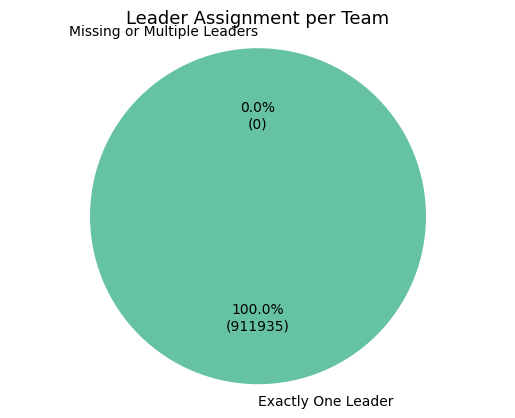

<ipython-input-4-51fb94ba3e75>:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=ei_melted, x="EI", y="Count", estimator=sum, ci=None)


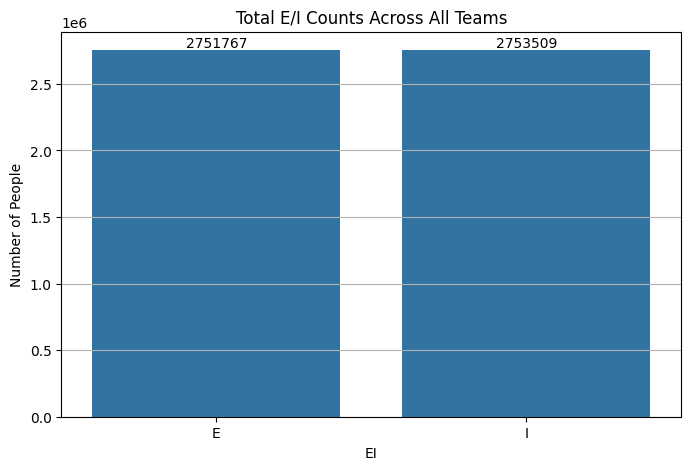

<ipython-input-4-51fb94ba3e75>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=temp_df, x="temperament", y="Count", palette="pastel")


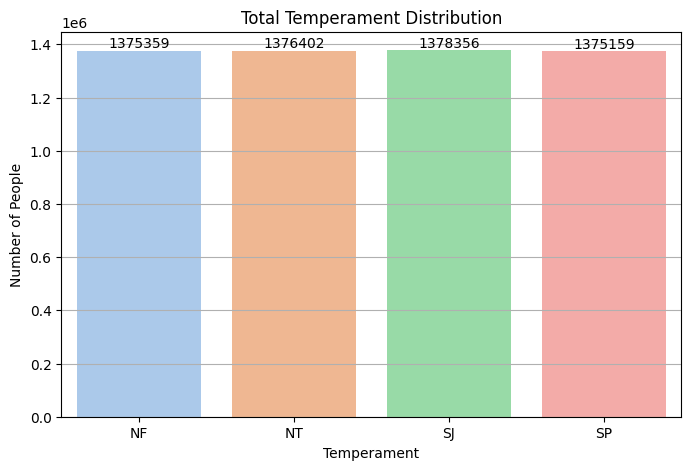

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_team_stats_detailed(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["team_number"].notna()]  # remove failed simulations

    # ✅ 1. Pie Chart: Percentage of teams with exactly one leader
    leader_check = df[df["is_leader"] == True].groupby(["simulation_index", "team_number"]).size().reset_index(name="leader_count")
    leader_check["valid"] = leader_check["leader_count"] == 1
    valid_count = leader_check["valid"].sum()
    invalid_count = len(leader_check) - valid_count

    labels = ["Exactly One Leader", "Missing or Multiple Leaders"]
    values = [valid_count, invalid_count]
    colors = ["#66c2a5", "#fc8d62"]

    plt.figure()
    wedges, texts, autotexts = plt.pie(
        values,
        labels=labels,
        autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100*sum(values)))})',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10}
    )
    plt.title("Leader Assignment per Team", fontsize=13)
    plt.axis("equal")
    plt.show()

    # ✅ 2. E/I bar chart with counts on bars
    ei_df = df.groupby(["simulation_index", "team_number", "ei"]).size().unstack(fill_value=0).reset_index()
    ei_melted = ei_df.melt(id_vars=["simulation_index", "team_number"], value_vars=["E", "I"], var_name="EI", value_name="Count")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=ei_melted, x="EI", y="Count", estimator=sum, ci=None)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.title("Total E/I Counts Across All Teams")
    plt.ylabel("Number of People")
    plt.grid(True, axis='y')
    plt.show()

    # ✅ 3. Temperament counts bar chart with counts on bars
    temp_df = df.groupby("temperament").size().reset_index(name="Count")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=temp_df, x="temperament", y="Count", palette="pastel")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.title("Total Temperament Distribution")
    plt.xlabel("Temperament")
    plt.ylabel("Number of People")
    plt.grid(True, axis='y')
    plt.show()

# Example usage
visualize_team_stats_detailed("team_simulation_detailed.csv")

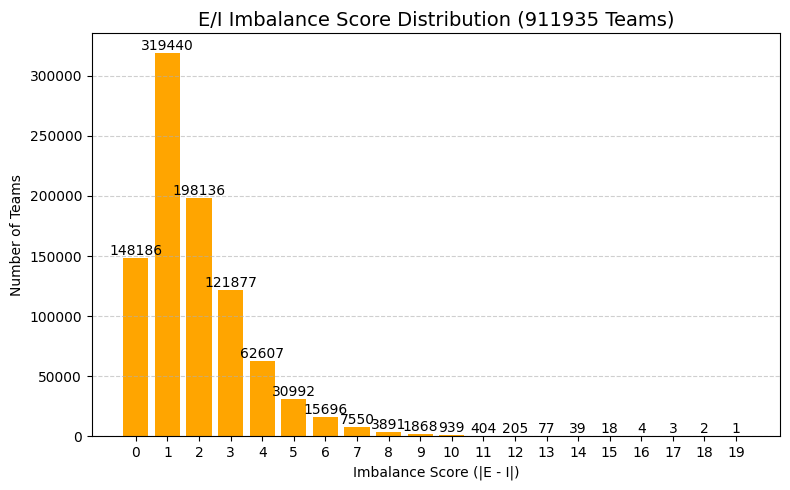

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_ei_imbalance(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["team_number"].notna()]  # remove failed simulations

    # Count E and I per team
    ei_counts = df.groupby(["simulation_index", "team_number", "ei"]).size().unstack(fill_value=0).reset_index()
    ei_counts["imbalance_score"] = abs(ei_counts["E"] - ei_counts["I"])

    # Count how many teams have each imbalance score
    imbalance_distribution = ei_counts["imbalance_score"].value_counts().sort_index()

    # Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(imbalance_distribution.index, imbalance_distribution.values, color='orange')

    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     ha='center', va='bottom', fontsize=10)

    total_teams = ei_counts.shape[0]
    plt.title(f"E/I Imbalance Score Distribution ({total_teams} Teams)", fontsize=14)
    plt.xlabel("Imbalance Score (|E - I|)")
    plt.ylabel("Number of Teams")
    plt.xticks(imbalance_distribution.index)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Example usage
plot_ei_imbalance("team_simulation_detailed.csv")

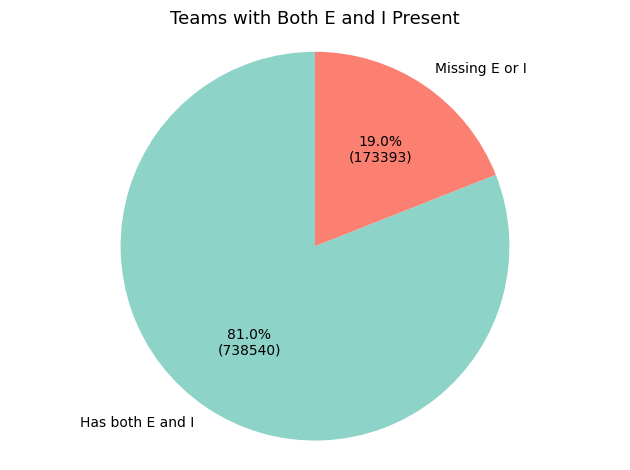

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_ei_coverage_pie(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["team_number"].notna()]

    # Count E and I per team
    ei_counts = df.groupby(["simulation_index", "team_number", "ei"]).size().unstack(fill_value=0).reset_index()
    ei_counts["has_E_and_I"] = (ei_counts["E"] > 0) & (ei_counts["I"] > 0)

    both = ei_counts["has_E_and_I"].sum()
    not_both = len(ei_counts) - both

    # Pie chart
    labels = ["Has both E and I", "Missing E or I"]
    sizes = [both, not_both]
    colors = ["#8dd3c7", "#fb8072"]

    plt.figure()
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=labels,
        autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100*sum(sizes))})",
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10}
    )
    plt.title("Teams with Both E and I Present", fontsize=13)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

# Example usage
plot_ei_coverage_pie("team_simulation_detailed.csv")

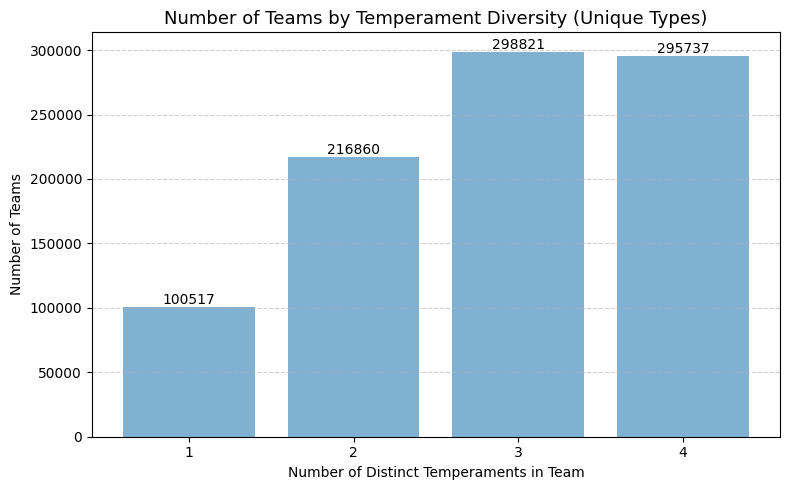

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_temperament_coverage_bar(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["team_number"].notna()]

    # Count distinct temperaments per team
    temp_counts = df.groupby(["simulation_index", "team_number"])["temperament"].nunique().value_counts().sort_index()

    # Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(temp_counts.index, temp_counts.values, color="#80b1d3")

    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     ha='center', va='bottom', fontsize=10)

    plt.title("Number of Teams by Temperament Diversity (Unique Types)", fontsize=13)
    plt.xlabel("Number of Distinct Temperaments in Team")
    plt.ylabel("Number of Teams")
    plt.xticks([1, 2, 3, 4])
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Example usage
plot_temperament_coverage_bar("team_simulation_detailed.csv")